# Day 3 Lab — Deep Learning for Time-Series Anomalies

This is a **guided instructor-led lab**, not just a code dump.

## Lab goals
1. Build a leakage-safe windowing pipeline for univariate anomaly detection.
2. Train a **Dense Autoencoder** and an **LSTM Autoencoder** on mostly-normal windows.
3. Compare them against a professional baseline: **Isolation Forest**.
4. Interpret the score traces, thresholds, and metric differences.

## Real-data schema
- required: `timestamp`, `value`
- optional: `is_anomaly`

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.ensemble import IsolationForest
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSV_PATH = None  # replace with a local CSV path when moving to real data
EXPORT_FIGURES = True

def resolve_pack_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent]:
        if (candidate / 'notebooks').exists() and (candidate / 'slides').exists():
            return candidate
    return cwd

PACK_ROOT = resolve_pack_root()
FIG_DIR = PACK_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('device =', device)
print('CSV_PATH =', CSV_PATH)

device = cpu
CSV_PATH = None


## Step 1 — Load a teachable series

The synthetic series includes three anomaly families:
- a spike cluster,
- a collective dip,
- and a gradual drift.

The point of the synthetic demo is not realism. It is to create a clean classroom example where different detectors have visibly different behavior.

In [2]:
def make_synthetic_series(n=1800, freq='5min'):
    ts = pd.date_range('2024-01-01', periods=n, freq=freq)
    base = 1.0 + 0.25 * np.sin(np.linspace(0, 14 * np.pi, n))
    base += 0.08 * np.sin(np.linspace(0, 3 * np.pi, n))
    noise = np.random.normal(0, 0.045, size=n)
    values = base + noise
    labels = np.zeros(n, dtype=int)

    anomalies = [
        (1120, 1130, 1.20),
        (1320, 1370, -0.45),
        (1540, 1620, np.linspace(0.0, 0.70, 80)),
    ]
    for start, end, delta in anomalies:
        values[start:end] += delta
        labels[start:end] = 1

    return pd.DataFrame({'timestamp': ts, 'value': values, 'is_anomaly': labels})


def load_series(csv_path=None):
    if csv_path and Path(csv_path).exists():
        df = pd.read_csv(csv_path, parse_dates=['timestamp']).sort_values('timestamp')
        if 'value' not in df.columns:
            raise ValueError('CSV must contain a value column.')
        if 'is_anomaly' not in df.columns:
            df['is_anomaly'] = 0
        return df[['timestamp', 'value', 'is_anomaly']]
    return make_synthetic_series()


series_df = load_series(CSV_PATH)
print(series_df.head())
print('anomaly points =', int(series_df['is_anomaly'].sum()))

            timestamp     value  is_anomaly
0 2024-01-01 00:00:00  1.076074           0
1 2024-01-01 00:05:00  0.985563           0
2 2024-01-01 00:10:00  1.014534           0
3 2024-01-01 00:15:00  1.037915           0
4 2024-01-01 00:20:00  0.990584           0
anomaly points = 140


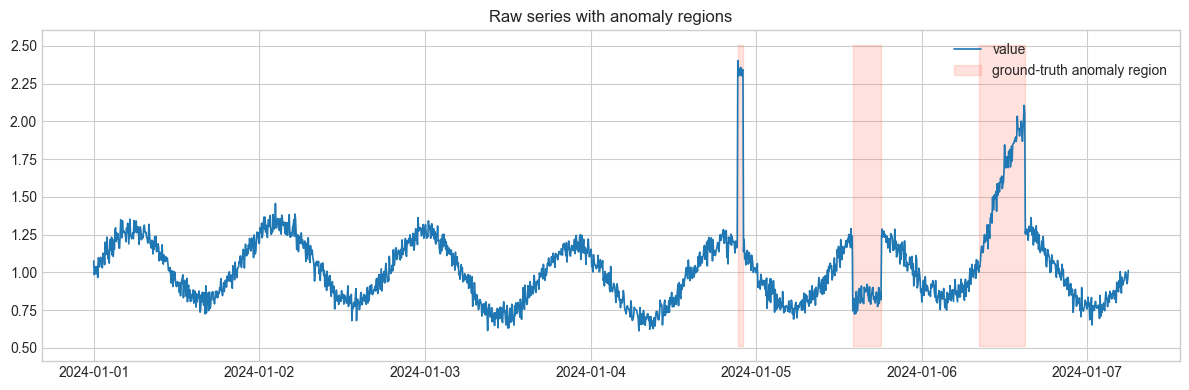

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series_df['timestamp'], series_df['value'], lw=1.2, label='value')
ax.fill_between(
    series_df['timestamp'],
    series_df['value'].min() - 0.1,
    series_df['value'].max() + 0.1,
    where=series_df['is_anomaly'].astype(bool),
    color='tomato',
    alpha=0.18,
    label='ground-truth anomaly region',
)
ax.set_title('Raw series with anomaly regions')
ax.legend(loc='upper right')
plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day3_series_overview.png', dpi=160, bbox_inches='tight')
plt.show()

### What learners should notice here
- The spike cluster is a good baseline test for Isolation Forest.
- The collective dip and drift are better tests of **window-based reconstruction**.
- If learners do not inspect the raw series first, later metric comparisons become much harder to interpret.

In [4]:
def build_window_dataset(df, window=48, train_frac=0.60, val_frac=0.20):
    values = df['value'].to_numpy(dtype=float)
    labels = df['is_anomaly'].to_numpy(dtype=int)
    timestamps = pd.to_datetime(df['timestamp'])

    windows, window_labels, end_times = [], [], []
    for start in range(len(df) - window + 1):
        end = start + window
        windows.append(values[start:end])
        window_labels.append(int(labels[start:end].max()))
        end_times.append(timestamps.iloc[end - 1])

    X = np.asarray(windows, dtype=np.float32)[..., None]
    y = np.asarray(window_labels, dtype=int)
    end_index = pd.to_datetime(end_times)

    n = len(X)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n)

    train_fit = X[train_idx][y[train_idx] == 0]
    if len(train_fit) == 0:
        train_fit = X[train_idx]

    mu = train_fit.mean(axis=(0, 1), keepdims=True)
    sigma = train_fit.std(axis=(0, 1), keepdims=True) + 1e-6
    X_scaled = (X - mu) / sigma

    return {
        'X': X_scaled,
        'y': y,
        'end_index': end_index,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'test_idx': test_idx,
        'window': window,
    }


def make_loader(array, batch_size=64, shuffle=False):
    tensor = torch.tensor(array, dtype=torch.float32)
    return DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=shuffle)


data = build_window_dataset(series_df, window=48)
for key in ['X', 'y', 'train_idx', 'val_idx', 'test_idx']:
    value = data[key]
    print(key, getattr(value, 'shape', len(value)))

X (1753, 48, 1)
y (1753,)
train_idx (1051,)
val_idx (350,)
test_idx (352,)


## Step 2 — Windowing and leakage-safe scaling

This is the most important operational discipline in the notebook.

What we want learners to say out loud:
- “The scaler was fit on training-normal windows only.”
- “The threshold came from training scores, not the full dataset.”
- “The split stayed contiguous in time.”

In [5]:
class DenseAE(nn.Module):
    def __init__(self, window, hidden=64, bottleneck=16):
        super().__init__()
        

    def forward(self, x):
        
        return out.view(-1, self.window, 1)


class LSTMAE(nn.Module):
    def __init__(self, input_dim=1, hidden=32):
        super().__init__()
        

    def forward(self, x):
       pass 


def train_autoencoder(model, train_loader, val_loader, epochs=5, lr=1e-3, loss_name='huber'):
    model = model.to(device)
    loss_fn = nn.HuberLoss(delta=1.0) if loss_name == 'huber' else nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best_state, best_val = None, float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        for batch, in train_loader:
            batch = batch.to(device)
            pred = model(batch)
            loss = loss_fn(pred, batch)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            val_losses = []
            for batch, in val_loader:
                batch = batch.to(device)
                pred = model(batch)
                val_losses.append(loss_fn(pred, batch).item())
            val_loss = float(np.mean(val_losses))

        print(f'epoch={epoch} val_loss={val_loss:.4f}')
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.to('cpu')
    return model


def reconstruction_scores(model, X):
    model.eval()
    with torch.no_grad():
        tensor = torch.tensor(X, dtype=torch.float32)
        recon = model(tensor).numpy()
    return np.mean((recon - X) ** 2, axis=(1, 2))


def point_metrics(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}

## Step 3 — Train the models and compare score behavior

The notebook keeps all three branches on the same split so the comparison is fair.

Interpretation goal:
- compare **score traces** first,
- compare **threshold crossings** second,
- and use scalar metrics only as the third layer of discussion.

In [6]:
X = data['X']
y = data['y']
train_idx, val_idx, test_idx = data['train_idx'], data['val_idx'], data['test_idx']

normal_train = X[train_idx][y[train_idx] == 0]
if len(normal_train) == 0:
    normal_train = X[train_idx]

train_loader = make_loader(normal_train, batch_size=64, shuffle=True)
val_loader = make_loader(X[val_idx], batch_size=64, shuffle=False)

window = X.shape[1]
dense = train_autoencoder(DenseAE(window=window), train_loader, val_loader, epochs=5, loss_name='huber')
lstm = train_autoencoder(LSTMAE(), train_loader, val_loader, epochs=5, loss_name='huber')

scores = {
    'dense_ae': reconstruction_scores(dense, X),
    'lstm_ae': reconstruction_scores(lstm, X),
}

iforest = IsolationForest(n_estimators=250, contamination=0.01, random_state=SEED)
iforest.fit(normal_train.reshape(len(normal_train), -1))
scores['isolation_forest'] = -iforest.score_samples(X.reshape(len(X), -1))

thresholds = {}
metrics = {}
for name, score in scores.items():
    train_score = score[train_idx][y[train_idx] == 0]
    if len(train_score) == 0:
        train_score = score[train_idx]
    thresholds[name] = float(np.quantile(train_score, 0.99))
    preds = (score[test_idx] > thresholds[name]).astype(int)
    metrics[name] = point_metrics(y[test_idx], preds)

metrics_df = pd.DataFrame(metrics).T.sort_values('f1', ascending=False)
print(metrics_df.round(3))
print()
print('thresholds =', {k: round(v, 4) for k, v in thresholds.items()})

ValueError: optimizer got an empty parameter list

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
axes[0].plot(series_df['timestamp'], series_df['value'], lw=1.2)
axes[0].fill_between(
    series_df['timestamp'],
    series_df['value'].min() - 0.1,
    series_df['value'].max() + 0.1,
    where=series_df['is_anomaly'].astype(bool),
    color='tomato',
    alpha=0.18,
)
axes[0].set_title('Series and anomaly regions')

for name, score in scores.items():
    axes[1].plot(data['end_index'], score, label=name)
    axes[1].axhline(thresholds[name], linestyle='--', alpha=0.6)

axes[1].set_title('Window scores and training thresholds')
axes[1].legend(loc='upper left')
plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day3_model_scores.png', dpi=160, bbox_inches='tight')
plt.show()

for name, score in scores.items():
    top = pd.DataFrame({
        'timestamp': data['end_index'][test_idx],
        'score': score[test_idx],
        'label': y[test_idx],
    }).sort_values('score', ascending=False).head(8)
    print()
    print(f'Top test windows for {name}:')
    print(top.to_string(index=False))


## Exercises
1. Change the loss from `huber` to `mse` and compare threshold stability.
2. Reduce the window from 48 to 24. Which anomaly type becomes easier or harder?
3. Force some anomalies into the training split. How much do the AE thresholds drift?
